# **Egyptian Car Plates OCR** 🖼️

## 1️⃣ Required Libraries

In [1]:
import cv2
import os
import shutil
import string
import itertools
import random
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau


2026-05-13 17:49:34.860964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778694574.884779    6635 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778694574.892399    6635 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778694574.910842    6635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778694574.910867    6635 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778694574.910869    6635 computation_placer.cc:177] computation placer alr

## 2️⃣ Read Dataset

In [2]:
# Constants
IMG_W, IMG_H = 256, 128
MAX_TEXT_LEN = 7
BATCH_SIZE = 32

# Map
label_map = {
    "0": "0", "1": "1", "2": "2", "3": "3", "4": "4", "5": "5", "6": "6", "7": "7", "8": "8", "9": "9",
    "zero": "0", "one": "1", "two": "2", "three": "3", "four": "4", "five": "5", "six": "6", "seven": "7", "eight": "8", "nine": "9",
    "alif": "A", "baa": "B", "taa": "C","thaa": "D", "jeem": "E", "7aa": "F", "khaa": "G", "daal": "H", "zaal": "I",
    "raa": "J", "zay": "K", "seen": "L", "sheen": "M", "saad": "N", "daad": "O", "taa_cap": "P", "tah": "P", "zaa": "Q", 
    "ain": "R", "ghayn": "S","faa": "T", "qaaf": "U", "kaaf": "V", "laam": "W", "meem": "n", "noon": "Y", "haa": "Z", 
    "waw": "a", "yaa": "b",

    "ا": "A", "ب": "B", "ت": "C", "ث": "D", "ج": "E", "ح": "F", "خ": "G", "د": "H", "ذ": "I",
    "ر": "J", "ز": "K", "س": "L", "ش": "M", "ص": "N", "ض": "O", "ط": "P", "ظ": "Q", "ع": "R", "غ": "S",
    "ف": "T", "ق": "U", "ك": "V", "ل": "W", "م": "n", "ن": "Y", "ه": "Z", "و": "a", "ى": "b"
}

en_to_ar = {v: k for k, v in label_map.items()}
unique_letters = sorted(set(label_map.values()))
unique_letters.append('X') 
CHAR_VECTOR = ''.join(unique_letters)
NUM_CLASSES = len(unique_letters) + 1 

In [3]:
def preprocess_label(label_list):
    new_label = ""
    for item in label_list:
        item_str = str(item).strip() 
        
        if item_str == "Taa":
            item_str = "tah"
        else:
            item_str = item_str.lower() 
            
        if item_str in label_map:
            new_label += label_map[item_str]
    
    final = new_label[::-1] 
    final = final.ljust(MAX_TEXT_LEN, 'X')
    return final[:MAX_TEXT_LEN]

def merge_and_prepare_data(csv_configs, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    all_dfs = []
    
    for config in csv_configs:
        path_csv = config['csv']
        path_img = config['images']
        
        df = pd.read_csv(path_csv, names=["name", "x1", "y1", "x2", "y2", "class_name"], header=None, skiprows=1)
        
        df_grouped = df.groupby("name")["class_name"].apply(list).reset_index()
        df_grouped.columns = ["name", "label_list"]
        df_grouped['label'] = df_grouped['label_list'].apply(preprocess_label)

        
        for img_name in df_grouped['name']:
            src = os.path.join(path_img, img_name)
            dst = os.path.join(output_dir, img_name)
            if os.path.exists(src):
                shutil.copy(src, dst)
        
        all_dfs.append(df_grouped)
    
    final_df = pd.concat(all_dfs, ignore_index=True)
    final_df.to_csv("final_labels.csv", index=False)
    return final_df

data_configs = [
    {'csv': '/kaggle/input/datasets/alyalsayed/egyptian-car-plates/train/_annotations.csv', 'images': '/kaggle/input/datasets/alyalsayed/egyptian-car-plates/train/'},
    {'csv': '/kaggle/input/datasets/alyalsayed/egyptian-car-plates/valid/_annotations.csv', 'images': '/kaggle/input/datasets/alyalsayed/egyptian-car-plates/valid/'}
]

merged_df = merge_and_prepare_data(data_configs, 'merged_plates')
train_df, val_df = train_test_split(merged_df, test_size=0.1, random_state=42)

## 3️⃣ Processing 

In [4]:
class PlateGenerator:
    def __init__(self, df, img_dir, batch_size, img_w, img_h, max_text_len, char_vector):
        self.df = df
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.img_w = img_w
        self.img_h = img_h
        self.max_text_len = max_text_len
        self.char_vector = char_vector
        self.n = len(df)
        self.indexes = np.arange(self.n)
        self.cur_index = 0
        np.random.shuffle(self.indexes) 

    def next_batch(self):
        while True:
            if self.cur_index == 0:
                np.random.shuffle(self.indexes)

            X = np.ones([self.batch_size, self.img_w, self.img_h, 1])
            Y = np.ones([self.batch_size, self.max_text_len])
            input_len = np.ones((self.batch_size, 1)) * 62
            label_len = np.zeros((self.batch_size, 1))

            i = 0
            while i < self.batch_size:
                if self.cur_index >= self.n:
                    self.cur_index = 0
                    np.random.shuffle(self.indexes)

                row = self.df.iloc[self.indexes[self.cur_index]]
                self.cur_index += 1

                img_path = os.path.join(self.img_dir, row['name'])
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img is None:
                    continue  
                    
                # Edge Enhancement
                kernel = np.array([[0, -1,  0],
                                   [-1,  5, -1],
                                   [0, -1,  0]])
                img = cv2.filter2D(img, -1, kernel)

                img = cv2.resize(img, (self.img_w, self.img_h)).astype(np.float32) / 255.0
                X[i] = img.T.reshape(self.img_w, self.img_h, 1)

                labels = [self.char_vector.index(c) for c in row['label']]
                Y[i, :len(labels)] = labels
                label_len[i] = len(labels)

                i += 1  

            yield (
                {
                    'the_input': X,
                    'the_labels': Y,
                    'input_length': input_len,
                    'label_length': label_len
                },
                np.zeros([self.batch_size])
            )
            
train_gen = PlateGenerator(
    df=train_df, 
    img_dir='merged_plates', 
    batch_size=BATCH_SIZE, 
    img_w=IMG_W, 
    img_h=IMG_H, 
    max_text_len=MAX_TEXT_LEN, 
    char_vector=CHAR_VECTOR
)

val_gen = PlateGenerator(
    df=val_df, 
    img_dir='merged_plates', 
    batch_size=BATCH_SIZE, 
    img_w=IMG_W, 
    img_h=IMG_H, 
    max_text_len=MAX_TEXT_LEN, 
    char_vector=CHAR_VECTOR
)

In [5]:
inputs, outputs = next(train_gen.next_batch())
sample_labels = inputs['the_labels'][0]
print("Decoded Sample Label:", "".join([CHAR_VECTOR[int(i)] for i in sample_labels if i < len(unique_letters)]))

Decoded Sample Label: 784SJXX


In [6]:
@tf.keras.utils.register_keras_serializable()
def ctc_loss_func(args):
    from tensorflow.keras import backend as K_inner
    y_pred, labels, input_length, label_length = args
    return K_inner.ctc_batch_cost(labels, y_pred, input_length, label_length)

@tf.keras.utils.register_keras_serializable()
def identity_loss(y_true, y_pred):
    return y_pred

## 4️⃣ Modeling

In [7]:
def build_model(training=True):
    inputs = layers.Input(name="the_input", shape=(IMG_W, IMG_H, 1))

    x = layers.GaussianNoise(stddev=0.03)(inputs)
    x = layers.RandomRotation(factor=0.04, fill_mode='nearest')(x)
    x = layers.RandomTranslation(height_factor=0.04, width_factor=0.06)(x)
    x = layers.RandomZoom(height_factor=(-0.08, 0.08), width_factor=(-0.08, 0.08))(x)
    x = layers.RandomContrast(factor=0.2)(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    conv_shape = x.shape
    x = layers.Reshape(
        target_shape=(int(conv_shape[1]), int(conv_shape[2] * conv_shape[3])),
        name='reshape')(x)

    x = layers.Dense(512, activation='relu', name='dense_bridge')(x)
    x = layers.Dropout(0.25)(x) 

    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.1))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.1))(x)

    x = layers.Dense(NUM_CLASSES, kernel_initializer='he_normal')(x)
    y_pred = layers.Activation('softmax', name='softmax')(x)

    labels = layers.Input(name="the_labels", shape=[MAX_TEXT_LEN], dtype="float32")
    input_length = layers.Input(name="input_length", shape=[1], dtype="int64")
    label_length = layers.Input(name="label_length", shape=[1], dtype="int64")

    loss_out = layers.Lambda(ctc_loss_func, name="ctc")(
        [y_pred, labels, input_length, label_length]
    )

    if training:
        return Model(inputs=[inputs, labels, input_length, label_length], outputs=loss_out)
    return Model(inputs=[inputs], outputs=y_pred)

In [8]:
model = build_model(training=True)
model.compile(loss=identity_loss, optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))

I0000 00:00:1778694592.604275    6635 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [9]:
checkpoint = ModelCheckpoint(
    'plate_ocr_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    save_weights_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    min_delta=0.1,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.6,
    patience=10,
    min_delta=0.1,
    min_lr=1e-5,
    cooldown=3,
    verbose=1
)

class SmoothValidation(tf.keras.callbacks.Callback):
    def __init__(self, alpha=0.4):
        self.alpha = alpha
        self.smoothed_val = None
    
    def on_epoch_end(self, epoch, logs=None):
        current_val = logs.get('val_loss')
        if self.smoothed_val is None:
            self.smoothed_val = current_val
        else:
            self.smoothed_val = self.alpha * current_val + (1 - self.alpha) * self.smoothed_val
        logs['val_loss'] = self.smoothed_val

smooth_cb = SmoothValidation(alpha=0.4)

history = model.fit(
    train_gen.next_batch(),
    steps_per_epoch=train_df.shape[0] // BATCH_SIZE,
    epochs=100,
    validation_data=val_gen.next_batch(),
    validation_steps=val_df.shape[0] // BATCH_SIZE,
    callbacks=[smooth_cb, checkpoint, early_stop, lr_scheduler]
)

Epoch 1/100


E0000 00:00:1778694599.812714    6635 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778694601.764143    6694 cuda_dnn.cc:529] Loaded cuDNN version 91002


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 49.5432
Epoch 1: val_loss improved from inf to 23.60830, saving model to plate_ocr_weights.weights.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 152ms/step - loss: 49.3452 - val_loss: 23.6083 - learning_rate: 1.0000e-04
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 23.0480
Epoch 2: val_loss improved from 23.60830 to 23.38724, saving model to plate_ocr_weights.weights.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - loss: 23.0430 - val_loss: 23.3872 - learning_rate: 1.0000e-04
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 21.1773
Epoch 3: val_loss did not improve from 23.38724
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - loss: 21.1745 - val_loss: 23.5029 - learning_rate: 1.0000e-04
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 19.9496
Epoch 4: val_loss improved from 23.38724 to 23.02042, saving model to plate_ocr_weights.weights.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - loss: 19.9492 - val_loss: 23.0204 

## 5️⃣ Evaluation

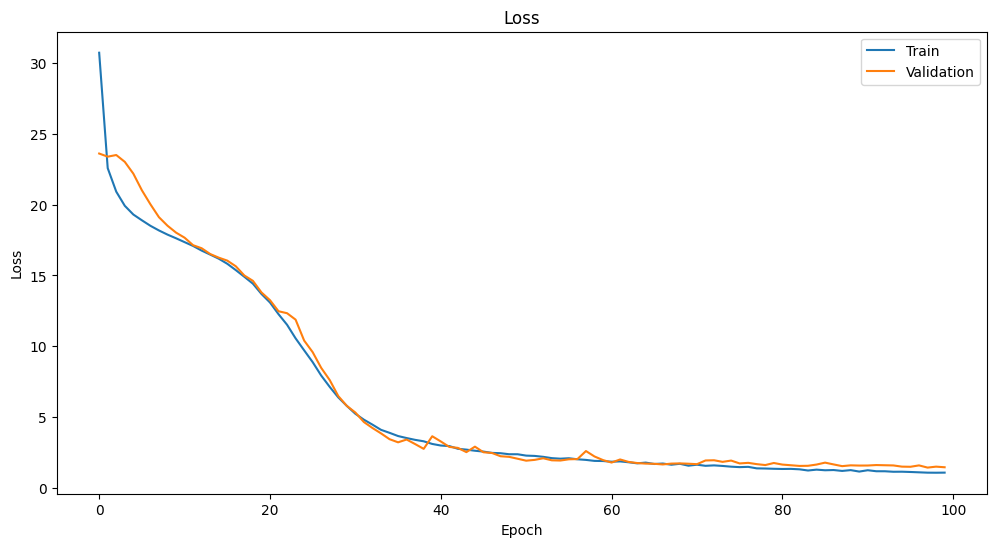

In [10]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

## 6️⃣ Testing

In [11]:
en_to_ar = {
    "A": "ا", "B": "ب", "C": "ت", "D": "ث", "E": "ج", "F": "ح", "G": "خ",
    "H": "د", "I": "ذ", "J": "ر", "K": "ز", "L": "س", "M": "ش", "N": "ص",
    "O": "ض", "P": "ط", "Q": "ظ", "R": "ع", "S": "غ", "T": "ف", "U": "ق",
    "V": "ك", "W": "ل", "n": "م", "Y": "ن", "Z": "هـ", "a": "و", "b": "ي",

    "0": "٠","1": "١","2": "٢","3": "٣","4": "٤","5": "٥","6": "٦","7": "٧",
    "8": "٨", "9": "٩"
}

In [14]:
def extract_text_from_plate(plate_img_bgr, weights_path):
    inf_model = build_model(training=False)
    inf_model.load_weights(weights_path)
    
    if plate_img_bgr is None: return "Error", ""
    
    gray = cv2.cvtColor(plate_img_bgr, cv2.COLOR_BGR2GRAY)
    
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    sharpened = cv2.filter2D(gray, -1, kernel)
    
    resized = cv2.resize(sharpened, (IMG_W, IMG_H)) 
    img_input = resized.T.reshape(1, IMG_W, IMG_H, 1)
    img_input = img_input.astype(np.float32) / 255.0
    
    preds = inf_model.predict(img_input)
    best_path = np.argmax(preds[0], axis=1)
    out_best = [k for k, g in itertools.groupby(best_path)]
    
    raw_text_en = "".join([CHAR_VECTOR[i] for i in out_best if i < len(unique_letters) and CHAR_VECTOR[i] != 'X'])
    text_en_correct = raw_text_en[::-1]
    
    text_ar = " ".join([en_to_ar[char] for char in text_en_correct if char in en_to_ar])
    return text_ar.strip(), text_en_correct

In [17]:
img_path = '/kaggle/input/datasets/nourhanabosaeed/plates-classification/plate colors/red/1753_license_plate_1.png'
img = cv2.imread(img_path)

if img is not None:
    result_ar, result_en = extract_text_from_plate(img, 'plate_ocr_weights.weights.h5')
    print(f"✅ Final Plate Text: {result_ar}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step
✅ Final Plate Text: س ن ب ٢ ٦ ٤ ٧


## **Thank You**🎀🫶🏻💓